In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [2]:
# 1. Load the Dataset
file_path = 'cleaned_child_malnutrition_data (1).csv'
df = pd.read_csv(file_path)

In [3]:
# 2. Data Overview
print("--- Dataset Information ---")
print(df.info())
print("\n--- Statistical Summary ---")
print(df.describe())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 6 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Country Name                                                    845 non-null    str    
 1   Year                                                            845 non-null    int64  
 2   Literacy rate, adult female (% of females ages 15 and above)    845 non-null    float64
 3   Pregnant women receiving prenatal care (%)                      845 non-null    float64
 4   Prevalence of stunting, height for age (% of children under 5)  845 non-null    float64
 5   Region_Type                                                     845 non-null    int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 39.7 KB
None

--- Statistical Summary ---
              Year  \
count   845.000000  

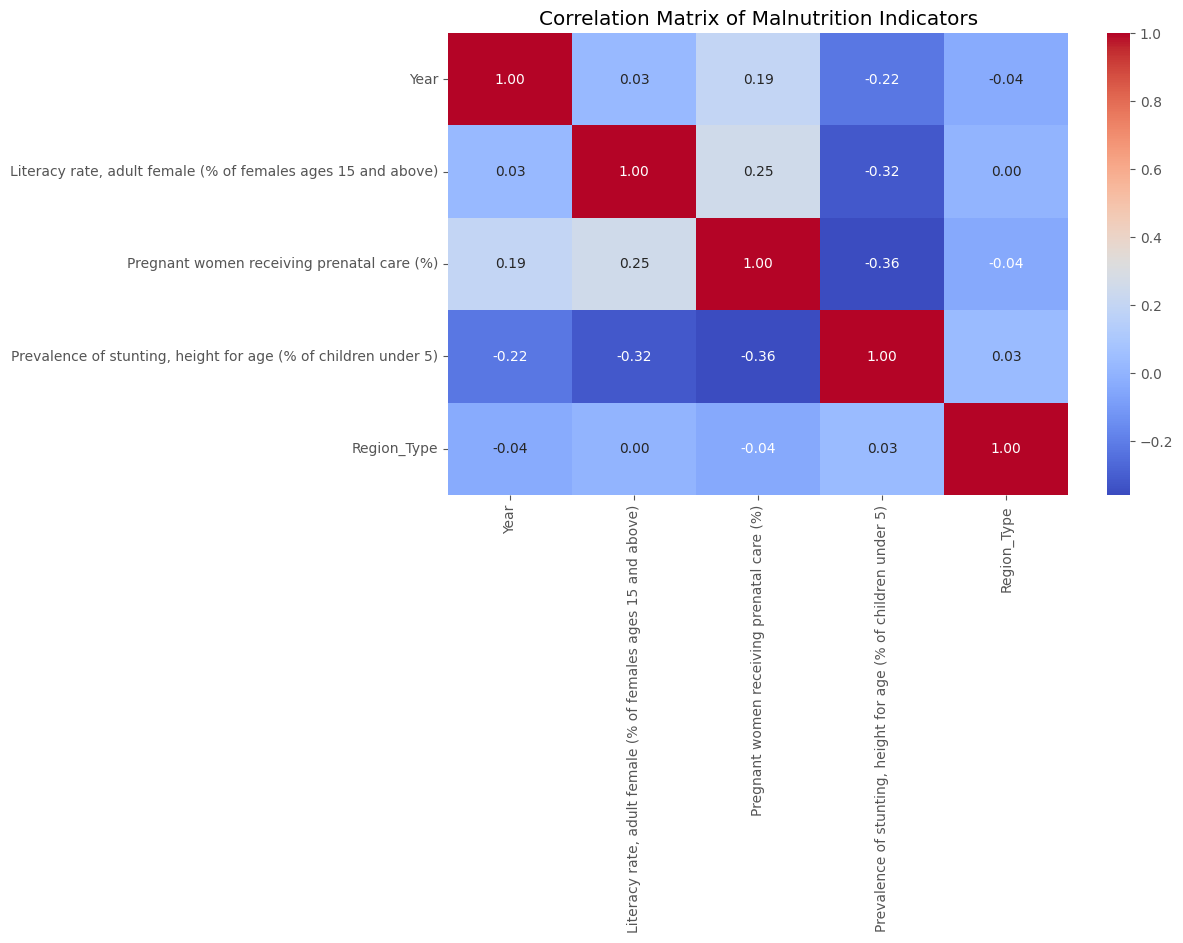

In [4]:
# 3. Exploratory Data Analysis (Visuals)
plt.style.use('ggplot')

# Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Malnutrition Indicators')
plt.show()

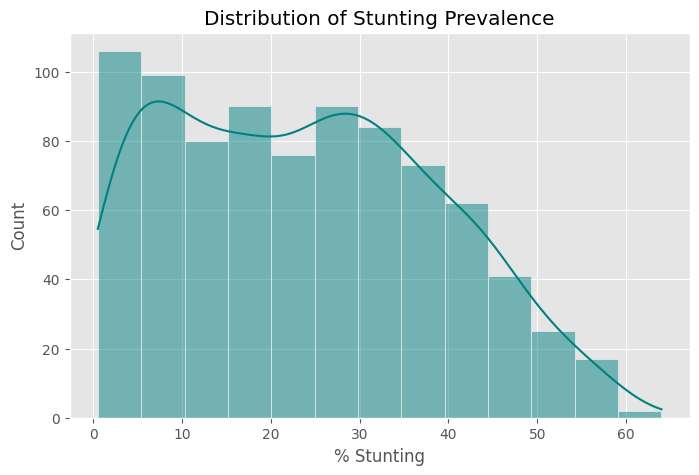

In [5]:
# Distribution of Target Variable: Stunting
plt.figure(figsize=(8, 5))
sns.histplot(df['Prevalence of stunting, height for age (% of children under 5)'], kde=True, color='teal')
plt.title('Distribution of Stunting Prevalence')
plt.xlabel('% Stunting')
plt.show()


In [6]:
# 4. Data Preparation for Modeling
# Defining Features (X) and Target (y)
# We exclude 'Country Name' as it is a categorical string, and 'Prevalence of stunting' which is our target.
target_col = 'Prevalence of stunting, height for age (% of children under 5)'
features = [col for col in df.columns if col not in [target_col, 'Country Name']]

X = df[features]
y = df[target_col]

# Splitting the data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:

# 5. Model Training (Random Forest Regressor)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Results ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")


--- Model Evaluation Results ---
Mean Absolute Error (MAE): 10.1197
Mean Squared Error (MSE): 171.3294
R-squared (R2 Score): 0.2381


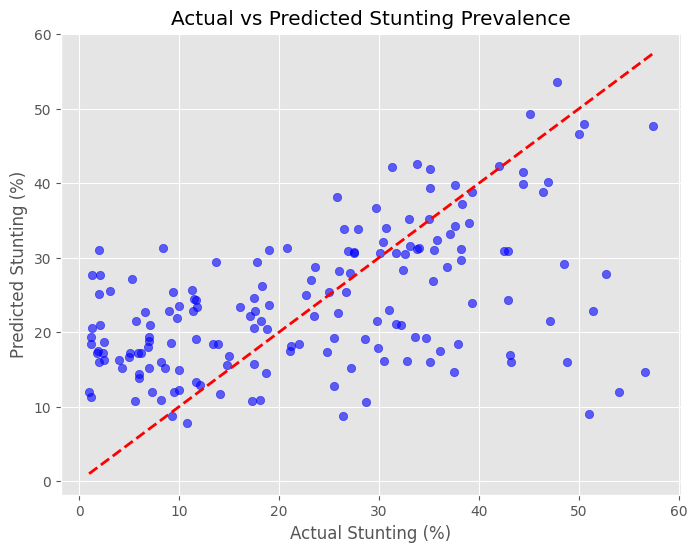

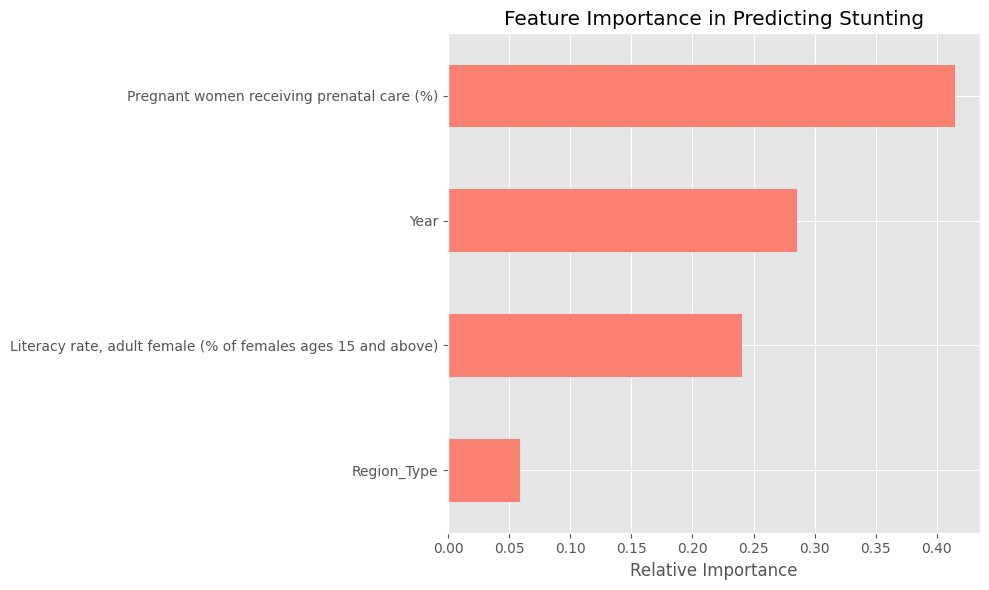

In [8]:
# 7. Visualization of Results
# Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Stunting (%)')
plt.ylabel('Predicted Stunting (%)')
plt.title('Actual vs Predicted Stunting Prevalence')
plt.show()

# Feature Importance
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='salmon')
plt.title('Feature Importance in Predicting Stunting')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()